In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1.

For n=7, x= [-1.00000000e+00 -8.66025404e-01 -5.00000000e-01 -6.12323400e-17
  5.00000000e-01  8.66025404e-01  1.00000000e+00]
For n=15, x= [-1.00000000e+00 -9.74927912e-01 -9.00968868e-01 -7.81831482e-01
 -6.23489802e-01 -4.33883739e-01 -2.22520934e-01 -6.12323400e-17
  2.22520934e-01  4.33883739e-01  6.23489802e-01  7.81831482e-01
  9.00968868e-01  9.74927912e-01  1.00000000e+00]


Text(0, 0.5, 'f(x)')

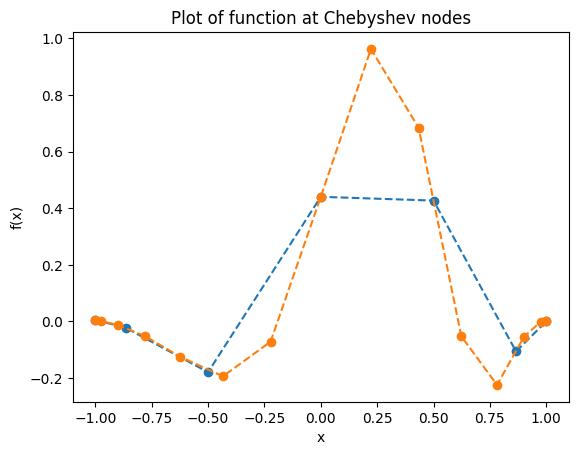

In [2]:
# define the function
def f1(x):
    return 100 * (x-1)**3 * np.cos(4*(x-1)) * np.exp(5*(x-1))

# define Chebyshev nodes
def Chebyshev(n):
    # n is the number of data points
    j = np.linspace(0,n-1,n)
    return -np.cos(j * np.pi / (n-1))

x_7 = Chebyshev(7)
x_15 = Chebyshev(15)
print("For n=7, x=",x_7) # check that the range is [-1,1]
print("For n=15, x=",x_15)

# plot the function at the Chebyshev nodes
data_7 = f1(x_7)
data_15 = f1(x_15)
plt.plot(x_7, data_7,'o--')
plt.plot(x_15, data_15,'o--')
plt.title("Plot of function at Chebyshev nodes")
plt.xlabel("x")
plt.ylabel("f(x)")

Text(0, 0.5, 'y')

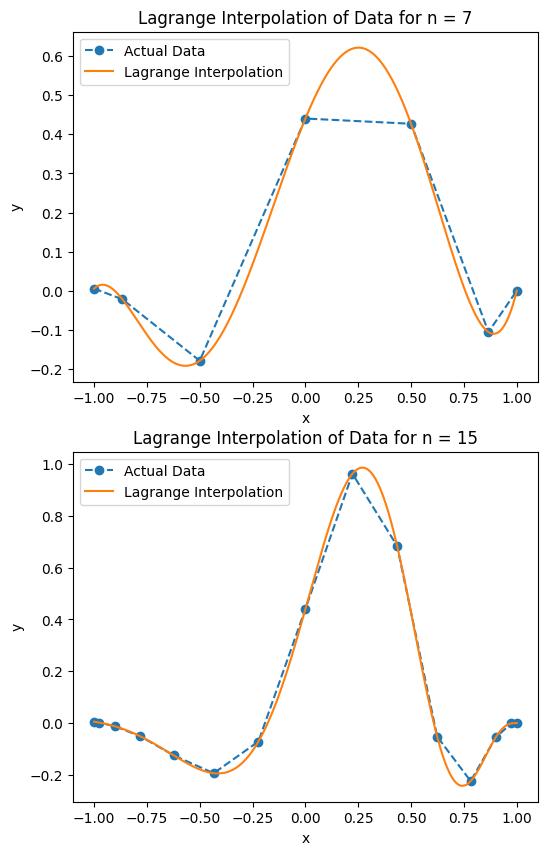

In [3]:
# implement Lagrange interpolation
def Lkx(xinterp, x, k): # define Lagrange Polynomials
    n=len(x)
    nplot = len(xinterp)
    Lkx = np.ones(nplot)
    for j in range (n):
        if (j==k): continue
        Lkx = Lkx*(xinterp-x[j])/(x[k]-x[j])
    return Lkx

def p(xinterp, x, y): # interpolated polynomial
    n = len(x)
    nplot = len(xinterp)
    pofx = np.zeros(nplot)
    for k in range(n):
        pofx = pofx + y[k]*Lkx(xinterp, x, k)
    return pofx

# set the plotting x values
n_plot = 1001
x_plot = np.linspace(-1,1,n_plot)

# do the interpolation
interpolation_7 = p(x_plot,x_7,data_7)
interpolation_15 = p(x_plot,x_15,data_15)

fig, axes = plt.subplots(2,1, figsize=(6,10))

axes[0].plot(x_7,data_7,'o--', label='Actual Data')
axes[0].plot(x_plot,interpolation_7,label='Lagrange Interpolation')
axes[0].legend()
axes[0].set_title("Lagrange Interpolation of Data for n = 7")
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].plot(x_15,data_15,'o--', label='Actual Data')
axes[1].plot(x_plot,interpolation_15,label='Lagrange Interpolation')
axes[1].legend()
axes[1].set_title("Lagrange Interpolation of Data for n = 15")
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# 2.

Text(0, 0.5, 'y')

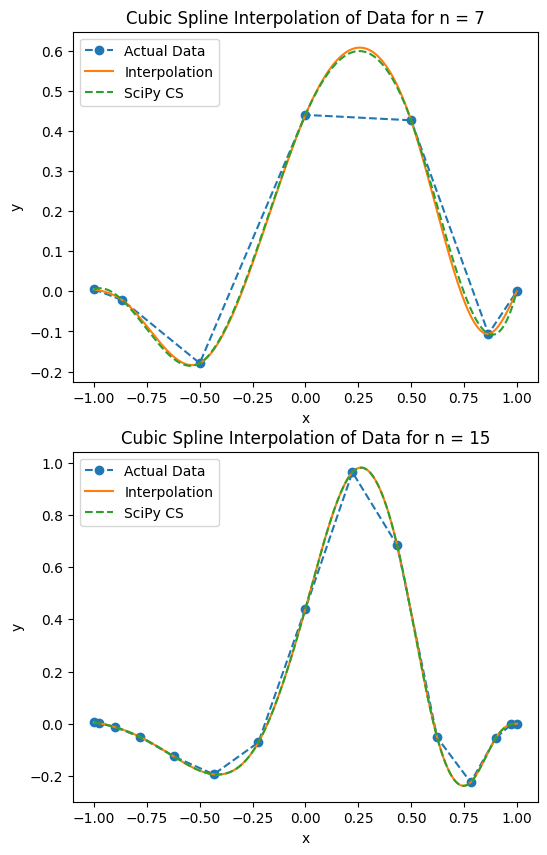

In [4]:
from scipy.interpolate import CubicSpline

def S(k,xi,x,y,c):
    s1=y[k-1]*(x[k]-xi)/(x[k]-x[k-1])
    s2=y[k]*(xi-x[k-1])/(x[k]-x[k-1])
    s3=-c[k-1]/6*((x[k]-xi)*(x[k]-x[k-1])-(x[k]-xi)**3/(x[k]-x[k-1]))
    s4=-c[k]/6*((xi-x[k-1])*(x[k]-x[k-1])-(xi-x[k-1])**3/(x[k]-x[k-1]))
    return s1+s2+s3+s4

def Cubic_Spline(x_plot, x, y):
    n = len(x)
    n_plot = len(x_plot)

    # Set up the symmetric, tridiagonal matrix M,
    # whose dimension is (n-2)x(n-2):
    M = np.zeros((n-2,n-2))
    M[0,0], M[0,1] = 2*(x[2]-x[0]), (x[2]-x[1]) # first row
    M[-1,-2], M[-1,-1] = (x[n-2]-x[n-3]), 2*(x[n-1]-x[n-3]) # last row

    for k in range(1,n-3):
        M[k,k-1] = x[k+1]-x[k]
        M[k,k]   = 2*(x[k+2]-x[k])
        M[k,k+1] = x[k+2]-x[k+1]
        
    b = np.zeros(n-2)
    # Note about the matrix element definitions:
    for i in range(n-2):
        k = i + 1 # this method is for k = 1,...,n-2
        b[i] = 6*((y[k+1]-y[k])/(x[k+1]-x[k])-(y[k]-y[k-1])/(x[k]-x[k-1])) # = bk

    c = np.linalg.solve(M, b)
    c=np.insert(c, 0, 0.0)
    c=np.insert(c, n-1, 0.0)

    y_interp = np.zeros(n_plot)

    for ii in range(n_plot):
        k=0
        for jj in range(n):
            if x_plot[ii] >= x[jj-1] and x_plot[ii] <=x[jj]: k = jj 
        y_interp[ii] = S(k, x_plot[ii],x, y, c)
    
    return y_interp

# Compute the interpolation. I'll use the Chebyshev nodes from problem 1 for simplicity
y_7 = Cubic_Spline(x_plot,x_7,data_7)
y_15 = Cubic_Spline(x_plot,x_15,data_15)

# Check work with SciPy Cubic Spline Interpolation
cs_7 = CubicSpline(x_7,data_7)
y_7_SP = cs_7(x_plot)

cs_15 = CubicSpline(x_15,data_15)
y_15_SP = cs_15(x_plot)

fig, axes = plt.subplots(2,1, figsize=(6,10))

axes[0].plot(x_7,data_7,'o--', label='Actual Data')
axes[0].plot(x_plot,y_7,label='Interpolation')
axes[0].plot(x_plot,y_7_SP,label='SciPy CS',ls='--')
axes[0].legend()
axes[0].set_title("Cubic Spline Interpolation of Data for n = 7")
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].plot(x_15,data_15,'o--', label='Actual Data')
axes[1].plot(x_plot,y_15,label='Interpolation')
axes[1].plot(x_plot,y_15_SP,label='SciPy CS',ls='--')
axes[1].legend()
axes[1].set_title("Cubic Spline Interpolation of Data for n = 15")
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# 3.

Text(0, 0.5, 'y')

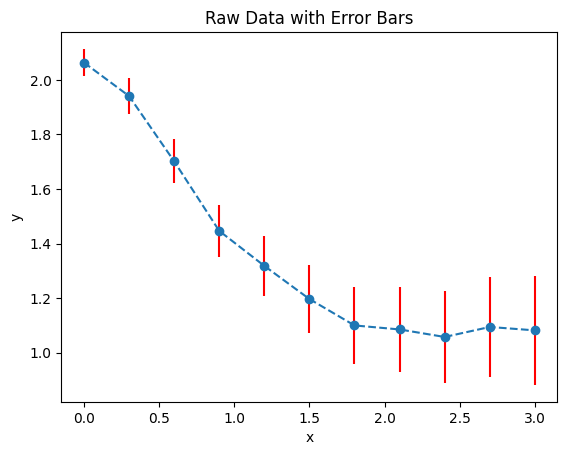

In [5]:
# import the data
data = np.loadtxt("DataHW6P3.txt")
data_x = data[:,0]
data_y = data[:,1]
data_error = data[:,2]
N = len(data_x)

# can create b vector that will be used in each part
b = np.zeros(N)
for i in range(N):
    b[i] = data_y[i] / data_error[i]

# define least square error function to use in each part
def LSE(y):
    sum = 0
    for j in range(N):
        sum += (data_y[j] - y[j])**2 / data_error[j]**2
    return sum

# visualize the data with error bars 
plt.errorbar(data_x,data_y,yerr=data_error,ecolor='r',marker="o",ls="--")
plt.title("Raw Data with Error Bars")
plt.xlabel('x')
plt.ylabel('y')

## a.
For this part, the fitting function is $p(x) = c_0 + c_1 x$ so $n=2$.

Least square error = 16.301033150556773


Text(0, 0.5, 'y')

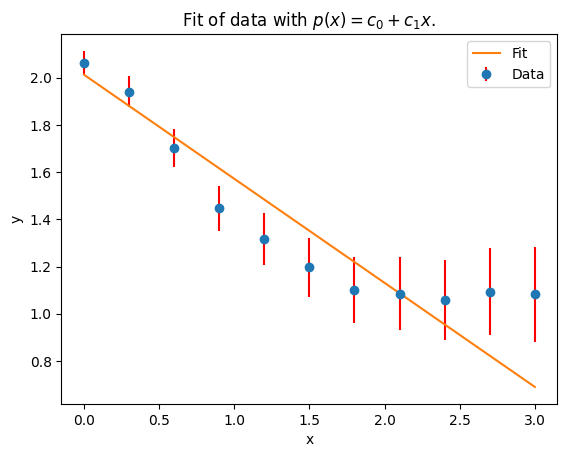

In [6]:
n = 2
def phia(k,x):
    if k == 0 : return 1
    elif k == 1 : return x

# Create A matrix
A = np.zeros((N,n))
for j in range(N):
    for k in range(n):
        A[j,k] = phia(k,data_x[j])/data_error[j]

# Solve for c vector
M1 = np.linalg.inv(np.matmul(np.transpose(A), A))
M2 = np.matmul(np.transpose(A),b)
c = np.matmul(M1,M2)

n_plot = 1001
x_plot = np.linspace(data_x[0],data_x[-1],n_plot)
y_plot= c[0] + c[1]*x_plot
y_fit = c[0] + c[1]*data_x
LSE_a = LSE(y_fit)
print("Least square error =",LSE_a)

plt.errorbar(data_x,data_y,yerr=data_error,ecolor='r',marker="o",ls="none",label="Data")
plt.plot(x_plot,y_plot,label="Fit")
plt.legend()
plt.title(rf"Fit of data with $p(x)=c_0 + c_1 x$.")
plt.xlabel('x')
plt.ylabel('y')

## b.

Least square error = 2.473962497605729


Text(0, 0.5, 'y')

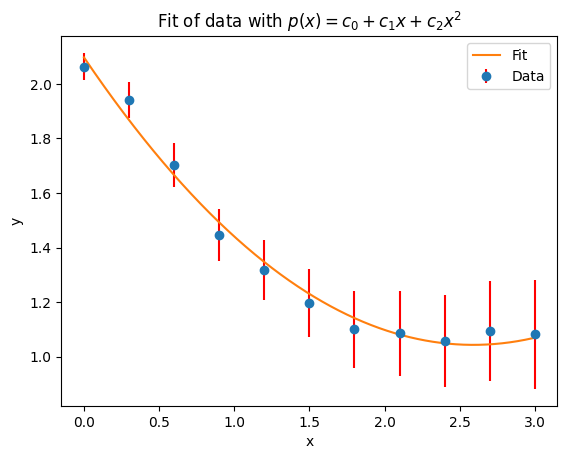

In [7]:
n = 3
def phib(k,x):
    if k == 0 : return 1
    elif k == 1 : return x
    elif k == 2 : return x**2

# Create A matrix
A = np.zeros((N,n))
for j in range(N):
    for k in range(n):
        A[j,k] = phib(k,data_x[j])/data_error[j]

# Solve for c vector
M1 = np.linalg.inv(np.matmul(np.transpose(A), A))
M2 = np.matmul(np.transpose(A),b)
c = np.matmul(M1,M2)

n_plot = 1001
x_plot = np.linspace(data_x[0],data_x[-1],n_plot)
y_plot = c[0] + c[1]*x_plot + c[2]*x_plot**2
y_fit = c[0] + c[1]*data_x + c[2]*data_x**2
LSE_a = LSE(y_fit)
print("Least square error =",LSE_a)

plt.errorbar(data_x,data_y,yerr=data_error,ecolor='r',marker="o",ls="none",label="Data")
plt.plot(x_plot,y_plot,label="Fit")
plt.legend()
plt.title(r"Fit of data with $p(x)=c_0 + c_1 x + c_2 x^2$")
plt.xlabel('x')
plt.ylabel('y')

## c.

Least square error = 1.7243619100191028


Text(0, 0.5, 'y')

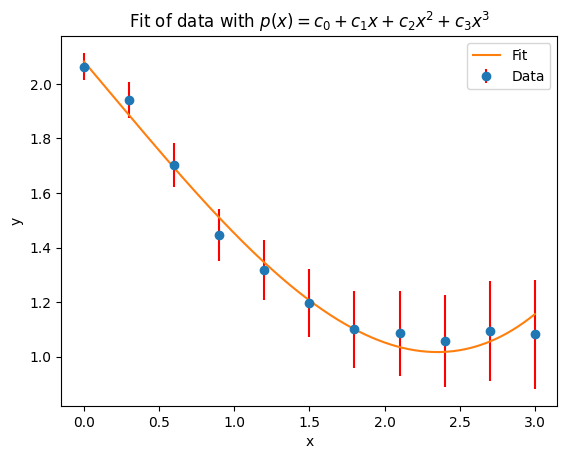

In [8]:
n = 4
def phib(k,x):
    if k == 0 : return 1
    elif k == 1 : return x
    elif k == 2 : return x**2
    elif k == 3 : return x**3

# Create A matrix
A = np.zeros((N,n))
for j in range(N):
    for k in range(n):
        A[j,k] = phib(k,data_x[j])/data_error[j]

# Solve for c vector
M1 = np.linalg.inv(np.matmul(np.transpose(A), A))
M2 = np.matmul(np.transpose(A),b)
c = np.matmul(M1,M2)

n_plot = 1001
x_plot = np.linspace(data_x[0],data_x[-1],n_plot)
y_plot = c[0] + c[1]*x_plot + c[2]*x_plot**2 + c[3]*x_plot**3
y_fit = c[0] + c[1]*data_x + c[2]*data_x**2 + c[3]*data_x**3
LSE_a = LSE(y_fit)
print("Least square error =",LSE_a)

plt.errorbar(data_x,data_y,yerr=data_error,ecolor='r',marker="o",ls="none",label="Data")
plt.plot(x_plot,y_plot,label="Fit")
plt.legend()
plt.title(r"Fit of data with $p(x)=c_0 + c_1 x + c_2 x^2 + c_3 x^3$")
plt.xlabel('x')
plt.ylabel('y')

## d.

Least square error = 1.0022457114414456


Text(0, 0.5, 'y')

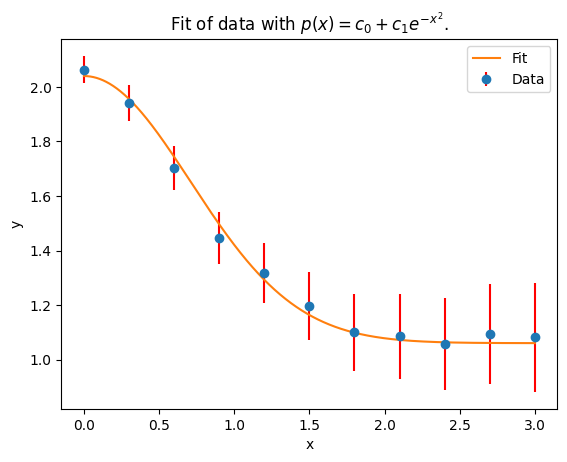

In [9]:
n = 2
def phia(k,x):
    if k == 0 : return 1
    elif k == 1 : return np.exp(-(x**2))

# Create A matrix
A = np.zeros((N,n))
for j in range(N):
    for k in range(n):
        A[j,k] = phia(k,data_x[j])/data_error[j]

# Solve for c vector
M1 = np.linalg.inv(np.matmul(np.transpose(A), A))
M2 = np.matmul(np.transpose(A),b)
c = np.matmul(M1,M2)

n_plot = 1001
x_plot = np.linspace(data_x[0],data_x[-1],n_plot)
y_plot = c[0] + c[1]*np.exp(-(x_plot**2))
y_fit = c[0] + c[1]*np.exp(-(data_x**2))
LSE_a = LSE(y_fit)
print("Least square error =",LSE_a)

plt.errorbar(data_x,data_y,yerr=data_error,ecolor='r',marker="o",ls="none",label="Data")
plt.plot(x_plot,y_plot,label="Fit")
plt.legend()
plt.title(r"Fit of data with $p(x)=c_0 + c_1 e^{-x^2}$.")
plt.xlabel('x')
plt.ylabel('y')